<a href="https://colab.research.google.com/github/Dripp234/AIML/blob/main/CNN_brain_DAY_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import cv2
import numpy as np

zip_path = "/content/archive (21).zip" # Double-check your zip file name in the Colab sidebar
extract_path = "extracted_images"

print("Step 1: Extracting dataset...")
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
else:
    print(f"ERROR: Could not find '{zip_path}'. Make sure your zip file is uploaded directly to the /content/ folder in Colab.")

X = []
y = []

# Your exact folder structure: 'no' for healthy, 'yes' for tumor
folder_mapping = {
    'no': 0,
    'yes': 1
}

for root, dirs, files_in_dir in os.walk(extract_path):
    folder_name = os.path.basename(root)
    if folder_name in folder_mapping:
        label = folder_mapping[folder_name]
        print(f"Loading folder '{folder_name}' mapped as Label: {label}...")

        for file in files_in_dir:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                img_path = os.path.join(root, file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is not None:
                    img_resized = cv2.resize(img, (64, 64))
                    X.append(img_resized)
                    y.append(label)

X = np.array(X)
y = np.array(y)
print(f"\nTotal images successfully processed into memory: {len(X)}")

Step 1: Extracting dataset...
Extraction complete!
Loading folder 'no' mapped as Label: 0...
Loading folder 'yes' mapped as Label: 1...
Loading folder 'no' mapped as Label: 0...
Loading folder 'yes' mapped as Label: 1...

Total images successfully processed into memory: 506


In [ ]:
from sklearn.model_selection import train_test_split

if len(X) == 0:
    print("STOP! Zero images were loaded. Go back and check your zip file name or folder structure.")
else:
    # Scale pixel intensities smoothly between 0.0 and 1.0
    X_scaled = X / 255.0

    # Reshape data to include the grayscale channel layer required by a CNN (batch, width, height, channels)
    X_scaled = X_scaled.reshape(-1, 64, 64, 1)

    # Split dataset: 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    print(f"Dataset Split complete -> Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Dataset Split complete -> Training samples: 404 | Testing samples: 102


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Step 3: Building CNN Model with Data Augmentation & Dropout...")

model = keras.Sequential([
    # Data Augmentation Layers to artificially expand our compact dataset
    layers.RandomFlip("horizontal_and_vertical", input_shape=(64, 64, 1)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Dropout to stop the model from simply memorizing the 253 training images
    layers.Dropout(0.5),

    # Sigmoid output for a crisp binary score (0.0 to 1.0)
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
print("Model compiled successfully!")

Step 3: Building CNN Model with Data Augmentation & Dropout...
Model compiled successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Step 4: Training model for 5 Epochs...
Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.8020 - loss: 0.4086 - val_accuracy: 0.7745 - val_loss: 0.5114
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.8391 - loss: 0.3862 - val_accuracy: 0.8235 - val_loss: 0.4428
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8119 - loss: 0.4191 - val_accuracy: 0.8333 - val_loss: 0.4225
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.8317 - loss: 0.3831 - val_accuracy: 0.8333 - val_loss: 0.4940
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8342 - loss: 0.3849 - val_accuracy: 0.7451 - val_loss: 0.6371
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.7946 - loss: 0.4216 - val_accuracy: 0.8137 - val_loss: 0.4256
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.8069 - loss: 0.3870 - val_accuracy: 0.8529 - val_loss: 0.3621
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0

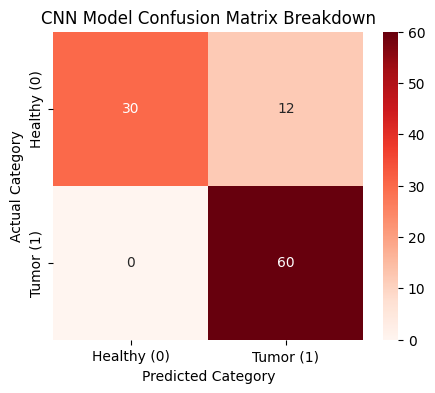

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Step 4: Training model for 5 Epochs...")
history = model.fit(X_train, y_train, epochs=15, batch_size=16, validation_data=(X_test, y_test))

print("\nRunning Evaluation Metrics on unseen Test Data...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n" + "="*40)
print(f"=== FINAL TEST DATA ACCURACY: {test_acc * 100:.2f}% ===")
print("="*40 + "\n")

# Predict values
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print("Classification Matrix Breakdown:")
print(classification_report(y_test, y_pred, target_names=['Healthy (No)', 'Tumor (Yes)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Healthy (0)', 'Tumor (1)'],
            yticklabels=['Healthy (0)', 'Tumor (1)'])
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('CNN Model Confusion Matrix Breakdown')
plt.show()

In [ ]:
from google.colab import files
import io

print("="*50)
print("Step 5: LIVE TEST CONSOLE")
print("Upload a fresh MRI scan file to verify model detection:")
print("="*50)

uploaded = files.upload()

for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        # Match our preprocessing pipeline exactly
        img_resized = cv2.resize(img, (64, 64))
        img_scaled = img_resized / 255.0

        # Reshape to a 4D tensor: (1 image, 64 height, 64 width, 1 channel)
        img_input = img_scaled.reshape(1, 64, 64, 1)

        # Get the structural sigmoid score
        probability = model.predict(img_input, verbose=0)[0][0]

        print("\n" + "═"*40)
        print(f"FILE NAME PROCESSING: {filename}")
        print("═"*40)
        if probability > 0.5:
            print(f"ANALYSIS RESULT: YES (Pathological Tumor Activity Detected)")
            print(f"System Confidence Level: {probability * 100:.2f}%")
        else:
            print(f"ANALYSIS RESULT: NO (Normal Physiological Presentation)")
            print(f"System Confidence Level: {(1 - probability) * 100:.2f}%")
        print("═"*40 + "\n")
    else:
        print(f"Execution Error: Could not interpret file content for '{filename}'. Upload raw images only.")

Step 5: LIVE TEST CONSOLE
Upload a fresh MRI scan file to verify model detection:


Saving Image94.jpg to Image94.jpg

════════════════════════════════════════
FILE NAME PROCESSING: Image94.jpg
════════════════════════════════════════
ANALYSIS RESULT: NO (Normal Physiological Presentation)
System Confidence Level: 93.16%
════════════════════════════════════════

